<a href="https://colab.research.google.com/github/y7chinmay/Diabetes-Risk-Prediction-ML/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip Diabetes.zip

Archive:  Diabetes.zip
  inflating: diabetes.csv            


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("diabetes.csv")
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose             

Outcome
0    500
1    268
Name: count, dtype: int64


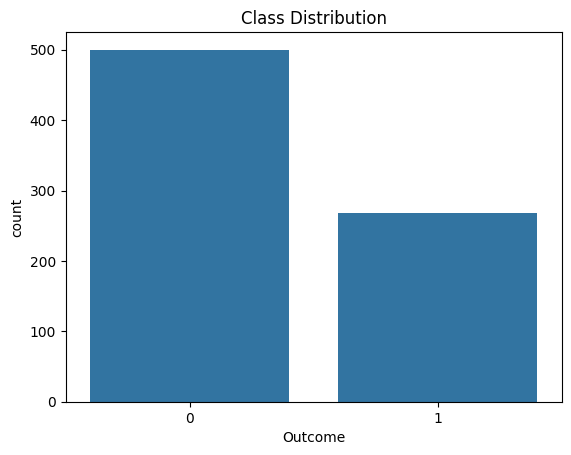

In [41]:
print(df['Outcome'].value_counts())
sns.countplot(x='Outcome', data=df )
plt.title('Class Distribution')
plt.show()

In [ ]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI']

print("Zero counts per column:")
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"  {col}: {zeros} zeros ({pct:.1f}%)")

Zero counts per column:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)


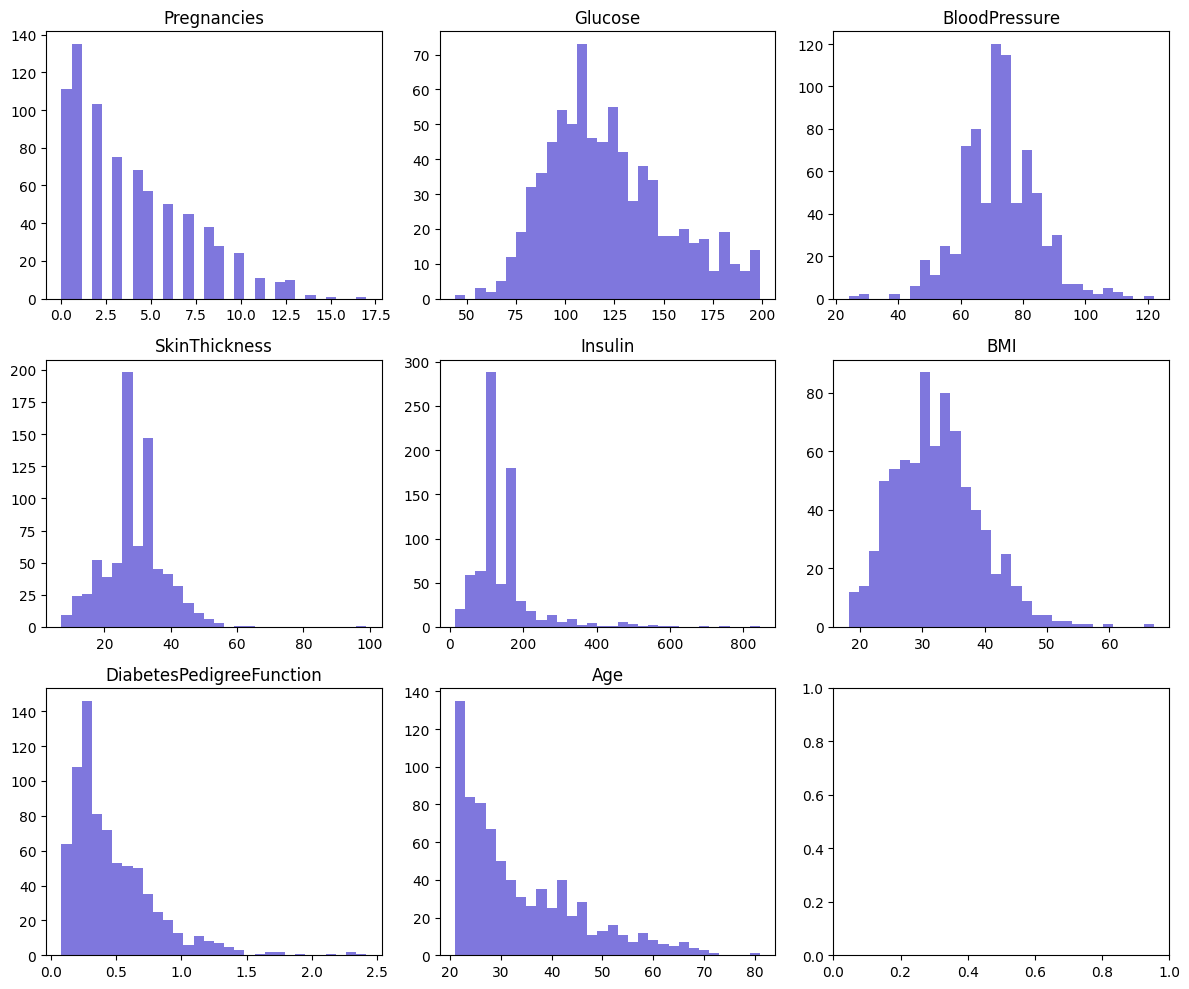

In [45]:
import os

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    axes[i].hist(df[col], bins=30,color='#7F77DD', alpha=1.0)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.tight_layout()


if not os.path.exists('data'):
    os.makedirs('data')

plt.savefig('data/distributions.png', dpi=150)
plt.show()

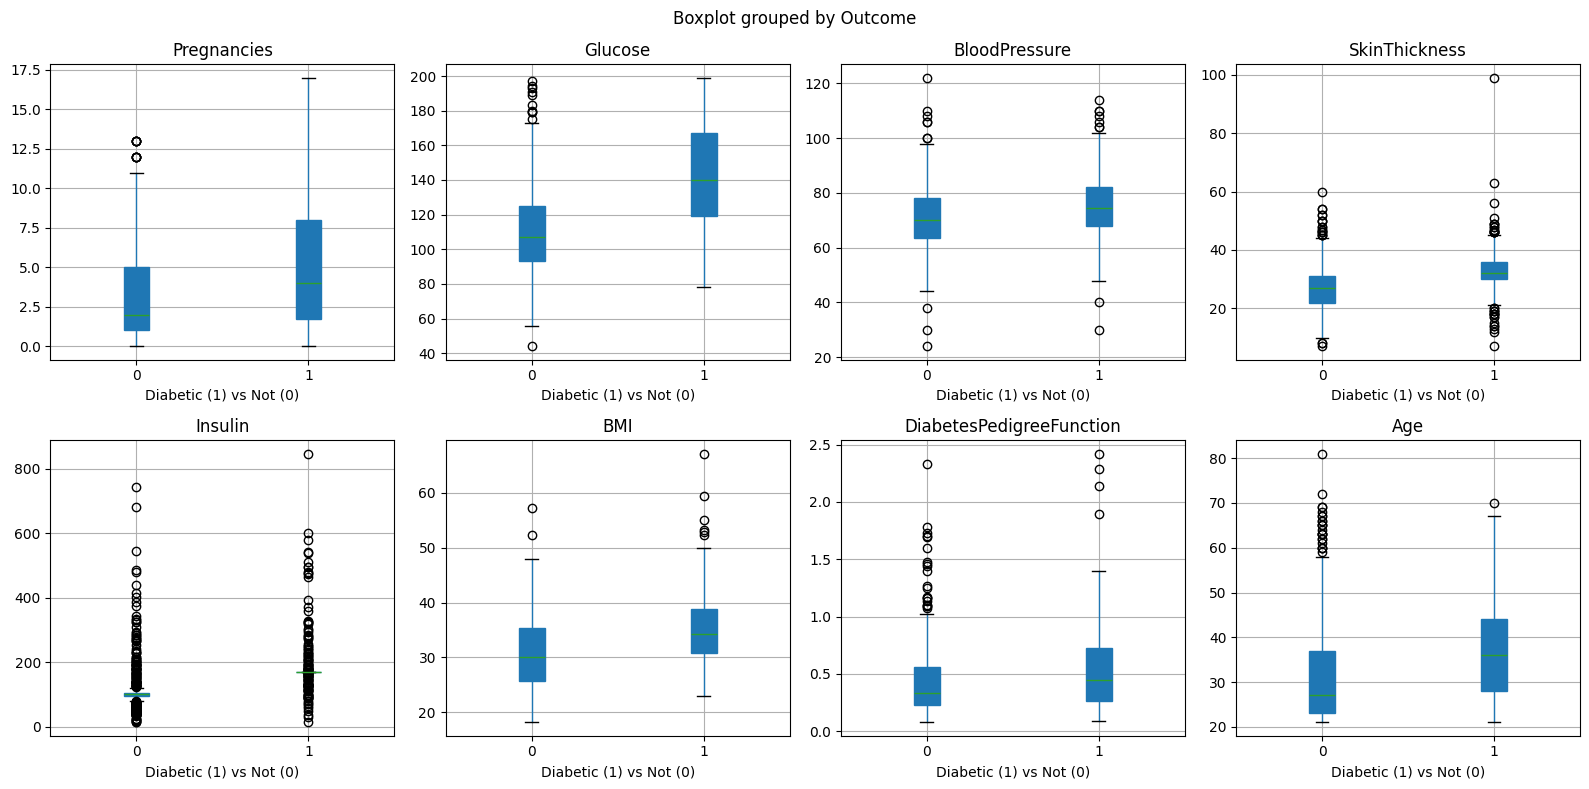

In [46]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns[:-1]):
    df.boxplot(column=col, by='Outcome', ax=axes[i],
               patch_artist=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('Diabetic (1) vs Not (0)')

plt.tight_layout()
plt.savefig('data/boxplots.png', dpi=150)
plt.show()

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv("diabetes.csv")
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median()))

print("Zeros reamaning:", (df[zero_cols] == 0).sum().sum())

Zeros reamaning: 0


In [48]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance:  {y_test.value_counts().to_dict()}")

Train: (614, 8), Test: (154, 8)
Train class balance: {0: 400, 1: 214}
Test class balance:  {0: 100, 1: 54}


In [49]:
import os

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


os.makedirs('model', exist_ok=True)

joblib.dump(scaler, 'model/scaler.pkl')
print("Scaler saved.")

Scaler saved.


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import joblib


In [51]:

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)
lr_cv = cross_val_score(lr, X_train_scaled, y_train,
                        cv=5, scoring='roc_auc').mean()
print(f"LR Cross-val AUC: {lr_cv:.3f}")

LR Cross-val AUC: 0.874


In [52]:

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
rf_cv = cross_val_score(rf, X_train_scaled, y_train,
                        cv=5, scoring='roc_auc').mean()
print(f"RF Cross-val AUC: {rf_cv:.3f}")

RF Cross-val AUC: 0.937


In [53]:

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train_scaled, y_train)
xgb_cv = cross_val_score(xgb, X_train_scaled, y_train,
                         cv=5, scoring='roc_auc').mean()
print(f"XGB Cross-val AUC: {xgb_cv:.3f}")

XGB Cross-val AUC: 0.942


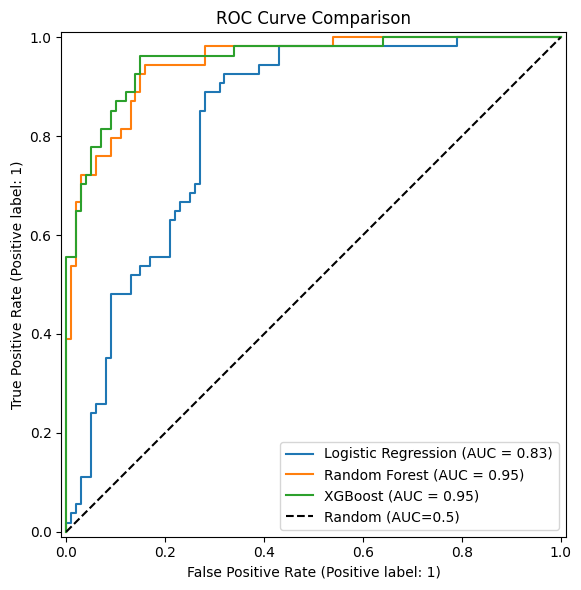

In [57]:
import os

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [("Logistic Regression", lr),
                     ("Random Forest", rf),
                     ("XGBoost", xgb)]:
    RocCurveDisplay.from_estimator(model, X_test_scaled,
                                   y_test, ax=ax, name=name)

ax.plot([0,1],[0,1],'k--', label='Random (AUC=0.5)')
ax.set_title('ROC Curve Comparison')
ax.legend(loc='lower right')
plt.tight_layout()


os.makedirs('data', exist_ok=True)

plt.savefig('data/roc_curves.png', dpi=150)
plt.show()


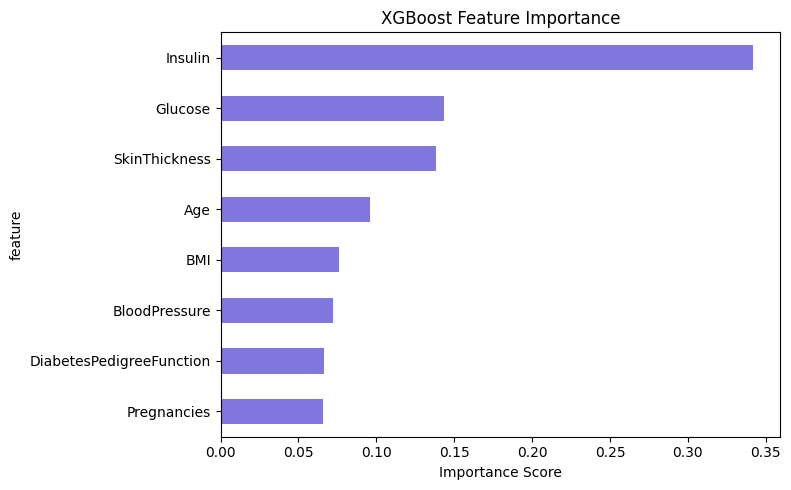

In [54]:

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=True)

feat_imp.plot(kind='barh', x='feature', y='importance',
              color='#7F77DD', figsize=(8, 5), legend=False)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150)
plt.show()

In [55]:

best_model = xgb

joblib.dump(best_model, 'model/diabetes_model.pkl')
joblib.dump(scaler,     'model/scaler.pkl')
joblib.dump(list(X.columns), 'model/feature_names.pkl')

print("Model saved  →  model/diabetes_model.pkl")
print("Scaler saved →  model/scaler.pkl")
print("Features     →  model/feature_names.pkl")

Model saved  →  model/diabetes_model.pkl
Scaler saved →  model/scaler.pkl
Features     →  model/feature_names.pkl


In [56]:
import joblib
import numpy as np
import pandas as pd


loaded_model = joblib.load('model/diabetes_model.pkl')
loaded_scaler = joblib.load('model/scaler.pkl')
loaded_feature_names = joblib.load('model/feature_names.pkl')
sample_data = pd.DataFrame([[
    6, 148, 72, 35, 169.5, 33.6, 0.627, 50
]], columns=loaded_feature_names)


sample_scaled = loaded_scaler.transform(sample_data)


prediction = loaded_model.predict(sample_scaled)[0]
probability = loaded_model.predict_proba(sample_scaled)[:, 1][0]

print(f"Prediction: {'Diabetic' if prediction == 1 else 'Not diabetic'}")
print(f"Probability of Diabetes: {probability:.2f}")

Prediction: Diabetic
Probability of Diabetes: 0.98
